# 09 - Model comparison and 2026-2028 projection

This notebook compares every saved run (36 valid models per track plus the oracle diagnostics), selects one model per track under the **amended selection protocol** of `CLAUDE.md` (rule 8) and projects 2026-2028 as extrapolation scenarios.

- **Selection** uses only rolling-origin pseudo-tests: fit before 2023-01-01 and test on 2023, fit before 2024-01-01 and test on 2024 (`reports/metrics/pseudotest_{track}.json`, produced by notebook 10). Settings of each model come from 3-fold time CV inside each fit window.
- **2025 is the final report year.** It is shown in every table as the out-of-sample result of the choice, but no 2025 row selects among candidates in Protocol B. The 2025 results were inspected in earlier iterations of the project; this is disclosed in the README.
- The one-standard-error rule uses the largest of the row, month-block and district-block bootstrap standard errors. A model counts as extrapolating when its projected path for a fixed profile changes beyond the last level (behavioural criterion); the old label is kept in the tables for comparison.
- Protocol A (the previous 2025-based selection) is recomputed in Step 2 only to show which winners change.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src' / 'rent_model').exists())
sys.path.insert(0, str(ROOT / 'src'))

import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rent_model import config
from rent_model.compare import (FAMILIES, annual_cash_cost, area_buckets, bootstrap_best_share, error_by_group,
                                extrapolation_kind, family_table, interval_multipliers, load_predictions, load_runs,
                                one_se_selection, ranking)
from rent_model.data import load_clean
from rent_model.features import select_track
from rent_model.hybrid import oracle_index
from rent_model.metrics import conservative_wape_diff, wape
from rent_model.projection import FUTURE, fit_scenario_model
from rent_model.splits import temporal_split

pd.set_option('display.float_format', '{:,.4f}'.format)
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 30)
plt.rcParams['figure.dpi'] = 100
config.FIGURES_DIR.mkdir(parents=True, exist_ok=True)
FAMILY_COLORS = dict(zip(FAMILIES, ['#9e9e9e', '#1f77b4', '#2ca02c', '#d62728', '#9467bd', '#ff7f0e', '#17becf']))
print('Random seed:', config.RANDOM_SEED)

Random seed: 42


## Step 1 - Leaderboard

In [2]:
runs = load_runs()
valid, invalid = ranking(runs)
print(f"{len(runs)} runs loaded ({runs['model_id'].nunique()} models x {runs['track'].nunique()} tracks); "
      f"valid {len(valid)}, excluded from the ranking (valid=False): {len(invalid)}")
show = ['rank', 'model_id', 'family', 'wape_pct', 'mae', 'mdape_pct', 'median_bias_pct', 'aggregate_bias_pct',
        'mape_dq_median_pct', 'rmse_log', 'r2_log', 'extrapolation', 'behaviour']
for track in config.TRACKS:
    print(f'{track}: leaderboard of the valid runs (top 15 of {int((valid.track == track).sum())}; the full table is saved to reports/metrics/leaderboard.csv)')
    display(valid[valid['track'] == track][show].head(15).set_index('rank'))

76 runs loaded (38 models x 2 tracks); valid 72, excluded from the ranking (valid=False): 4
jeonse: leaderboard of the valid runs (top 15 of 36; the full table is saved to reports/metrics/leaderboard.csv)


,model_id,family,wape_pct,mae,mdape_pct,median_bias_pct,aggregate_bias_pct,mape_dq_median_pct,rmse_log,r2_log,extrapolation,behaviour
rank,,,,,,,,,,,,
1,hgb_legal_dong_median,boosting,15.5379,"7,003.0677",12.0647,-6.3648,-7.7001,18.6545,0.2591,0.8824,none,level persistence
2,hgb_legal_dong,boosting,15.8354,"7,137.1232",12.6760,-7.3684,-8.5658,18.7190,0.2556,0.8855,none,level persistence
3,hybrid_hgb_median,time-series/hybrid,17.0894,"7,702.3313",12.4555,-2.1469,-3.9326,20.6286,0.2821,0.8605,forecasted index,level persistence
4,hgb_time_median,boosting,17.2212,"7,761.7316",12.4773,-2.5291,-3.5246,20.2380,0.2872,0.8555,tree time feature (cannot extrapolate),level persistence
5,hgb_time,boosting,17.3111,"7,802.2305",13.0657,-3.9480,-4.0113,19.9779,0.2817,0.8609,tree time feature (cannot extrapolate),level persistence
6,hgb_time_kmeans,unsupervised-assisted,17.3424,"7,816.3551",12.9657,-3.8072,-4.0169,19.9833,0.2822,0.8604,tree time feature (cannot extrapolate),not evaluated
7,hgb_time_tier,unsupervised-assisted,17.3508,"7,820.1270",13.0637,-3.9028,-3.9739,19.9843,0.2820,0.8607,tree time feature (cannot extrapolate),not evaluated
8,hgb_time_gmm,unsupervised-assisted,17.3771,"7,832.0040",13.0598,-3.9049,-4.0547,19.9316,0.2827,0.8600,tree time feature (cannot extrapolate),not evaluated
9,hybrid_hgb,time-series/hybrid,17.4448,"7,862.4920",12.9598,-3.3505,-5.0263,20.4127,0.2806,0.8620,forecasted index,level persistence


wolse: leaderboard of the valid runs (top 15 of 36; the full table is saved to reports/metrics/leaderboard.csv)


,model_id,family,wape_pct,mae,mdape_pct,median_bias_pct,aggregate_bias_pct,mape_dq_median_pct,rmse_log,r2_log,extrapolation,behaviour
rank,,,,,,,,,,,,
1,hgb_legal_dong_median,boosting,41.3097,30.9676,28.0125,-6.4869,-9.5688,88.2364,0.7050,0.3254,none,level persistence
2,hgb_detrended_median,boosting,42.4780,31.8434,28.6381,-6.1016,-10.2318,91.8463,0.7175,0.3013,log-linear trend (detrended),extrapolates
3,hgb_static_median,boosting,42.5756,31.9165,28.9372,-6.8068,-11.0302,90.9329,0.7159,0.3043,none,level persistence
4,hgb_time_median,boosting,42.6695,31.9869,29.2354,-4.9641,-9.1516,89.1187,0.7183,0.2997,tree time feature (cannot extrapolate),level persistence
5,hybrid_hgb_median,time-series/hybrid,43.0527,32.2742,29.8206,-9.5780,-13.6882,88.2559,0.7120,0.3118,forecasted index,extrapolates
6,hgb_legal_dong,boosting,44.3335,33.2343,35.3340,-16.9086,-21.6673,75.0369,0.6837,0.3655,none,level persistence
7,hgb_detrended,boosting,45.3293,33.9808,35.7666,-16.9244,-22.4758,77.0722,0.6942,0.3459,log-linear trend (detrended),extrapolates
8,hgb_static,boosting,45.5432,34.1412,36.0367,-17.6542,-23.2012,76.9509,0.6944,0.3454,none,level persistence
9,hgb_time_gmm,unsupervised-assisted,45.5640,34.1567,37.2668,-18.1697,-22.3026,76.3577,0.6959,0.3426,tree time feature (cannot extrapolate),not evaluated


**Interpretation.** The leaderboard is sorted by 2025 WAPE and is descriptive; it does not select models. In Jeonse the first two places are `hgb_legal_dong_median` (15.5379%) and `hgb_legal_dong` (15.8354%), followed by `hybrid_hgb_median` (17.0894%) and the time-feature boosting models (17.2212% to 17.3771%). The Jeonse median-loss variants are not uniformly better (`hgb_static_median` 18.1397% against `hgb_static` 18.5858%, but `hgb_detrended_median` 17.7049% against `hgb_detrended` 17.6481%). In Wolse the five median-loss variants occupy the first five places (41.3097% to 43.0527%) and the best squared-loss model, `hgb_legal_dong`, has 44.3335%. The aggregate bias is -21.6673% for that model and -9.5688% for `hgb_legal_dong_median`. The `mape_dq_median_pct` column moves in the opposite direction in Wolse (88.2364% for `hgb_legal_dong_median` against 75.0369% for `hgb_legal_dong`) while MdAPE falls (28.0125% against 35.3340%): the median loss predicts lower-rent contracts higher in relative terms, which inflates the percentage error of cheap contracts. The `behaviour` column shows the behavioural classification used in Step 2.

In [3]:
print('Excluded from the ranking: oracle diagnostics (use TEST information, not valid models)')
display(invalid[['track', 'model_id', 'family', 'wape_pct', 'median_bias_pct', 'aggregate_bias_pct', 'rmse_log', 'r2_log']].set_index(['track', 'model_id']))

Excluded from the ranking: oracle diagnostics (use TEST information, not valid models)


family  wape_pct  median_bias_pct  aggregate_bias_pct  rmse_log  r2_log
track  model_id                                                                                                
jeonse hybrid_hgb_oracle    time-series/hybrid   17.2465          -2.8474             -4.4224    0.2799  0.8627
       hybrid_ridge_oracle  time-series/hybrid   22.8945          -4.2523             -7.9031    0.3482  0.7875
wolse  hybrid_hgb_oracle    time-series/hybrid   44.8760         -15.0720            -20.9506    0.6936  0.3470
       hybrid_ridge_oracle  time-series/hybrid   49.3913         -15.3338            -24.2409    0.7435  0.2497

**Interpretation.** The oracle hybrids use the price index fitted with the test months and are not valid models. Their 2025 WAPE is 17.2465% (`hybrid_hgb_oracle`) and 22.8945% (`hybrid_ridge_oracle`) in Jeonse, and 44.8760% and 49.3913% in Wolse. The valid `hybrid_hgb` has 17.4448% in Jeonse and 46.1356% in Wolse: the gain from knowing the true index is therefore small in Jeonse (17.2465% against 17.4448%) and larger in Wolse (44.8760% against 46.1356%), but in neither track does it explain the gap to the best models.

### Family comparison

jeonse: WAPE by model family (valid runs)


,n_models,best_wape,median_wape,worst_wape,best_model
family,,,,,
baseline,6,27.2510,43.0806,55.5593,baseline_district_type_area
linear,8,23.0944,24.2070,24.3701,ridge_time_rich
forest,3,17.9051,17.9091,18.9266,rf_time
boosting,8,15.5379,17.4796,18.5858,hgb_legal_dong_median
unsupervised-assisted,6,17.3424,20.3839,24.0436,hgb_time_kmeans
pure unsupervised,2,37.0993,39.4306,41.7619,gmm_median
time-series/hybrid,3,17.0894,17.4448,23.1356,hybrid_hgb_median


wolse: WAPE by model family (valid runs)


,n_models,best_wape,median_wape,worst_wape,best_model
family,,,,,
baseline,6,46.9591,53.3475,56.5529,baseline_district_type_area
linear,8,49.0983,49.9677,51.3992,ridge_time_rich
forest,3,45.7560,45.9594,46.3507,rf_detrended
boosting,8,41.3097,43.5015,45.7417,hgb_legal_dong_median
unsupervised-assisted,6,45.5640,48.1180,51.3471,hgb_time_gmm
pure unsupervised,2,51.8733,53.1657,54.4581,gmm_median
time-series/hybrid,3,43.0527,46.1356,50.4930,hybrid_hgb_median


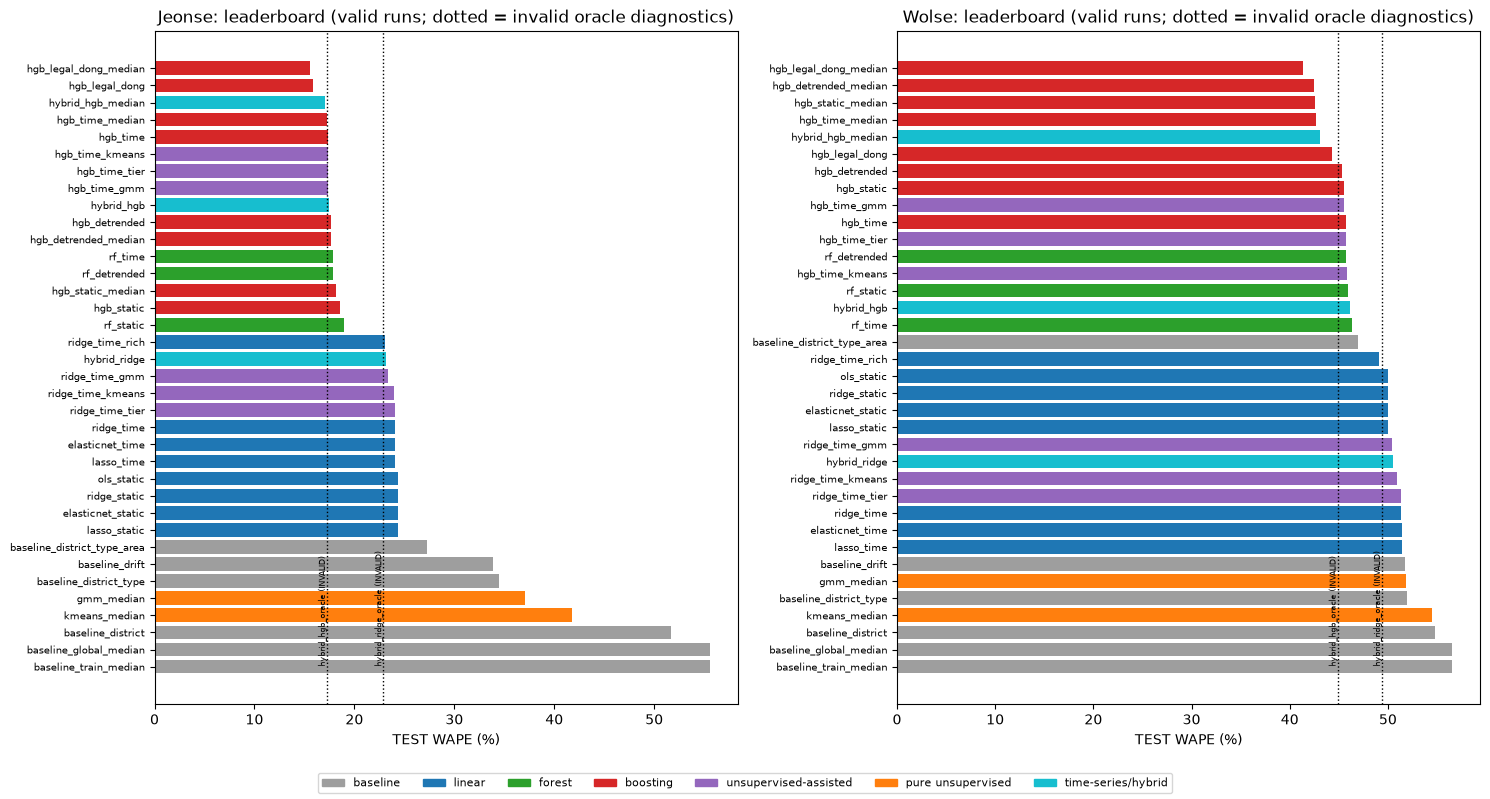

In [4]:
fam = family_table(valid)
for track in config.TRACKS:
    print(f'{track}: WAPE by model family (valid runs)')
    display(fam[fam['track'] == track].set_index('family').drop(columns='track').loc[[f for f in FAMILIES if f in set(fam[fam['track'] == track]['family'])]])

fig, axes = plt.subplots(1, 2, figsize=(15, 8))
for ax, track in zip(axes, config.TRACKS):
    v = valid[valid['track'] == track].sort_values('wape_pct', ascending=False)
    ax.barh(v['model_id'], v['wape_pct'], color=[FAMILY_COLORS[f] for f in v['family']])
    for _, r in invalid[invalid['track'] == track].iterrows():
        ax.axvline(r['wape_pct'], color='black', ls=':', lw=1)
        ax.text(r['wape_pct'], 0, r['model_id'] + ' (INVALID)', rotation=90, fontsize=6, va='bottom', ha='right')
    ax.set_xlabel('TEST WAPE (%)'); ax.set_title(f'{track.capitalize()}: leaderboard (valid runs; dotted = invalid oracle diagnostics)')
    ax.tick_params(axis='y', labelsize=7)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in FAMILY_COLORS.values()]
fig.legend(handles, FAMILY_COLORS.keys(), loc='lower center', ncol=7, fontsize=8)
plt.tight_layout(rect=(0, 0.04, 1, 1)); plt.savefig(config.FIGURES_DIR / '09_leaderboard.png', dpi=130); plt.show()

**Interpretation.** Boosting is the best family in both tracks (best WAPE 15.5379% in Jeonse and 41.3097% in Wolse, both `hgb_legal_dong_median`). In Jeonse the forest family follows closely (best 17.9051%, `rf_time`) and the time-series/hybrid family has 17.0894% (`hybrid_hgb_median`); linear models reach 23.0944% (`ridge_time_rich`), against 27.2510% for the best baseline. In Wolse the gaps are narrower: best forest 45.7560%, best hybrid 43.0527%, best linear 49.0983% and best baseline 46.9591%, so the best linear model is worse than the baseline in Wolse. Pure unsupervised models are the weakest families (37.0993% in Jeonse, 51.8733% in Wolse).

### Supervised vs unsupervised

In [5]:
wape_of = lambda track, model_id: float(runs[(runs['track'] == track) & (runs['model_id'] == model_id)]['wape_pct'].iloc[0])
pairs = [(f'{base}_{suffix}', base) for base in ['ridge_time', 'hgb_time'] for suffix in ['kmeans', 'tier', 'gmm']]
rows = []
for track in config.TRACKS:
    for assisted, plain in pairs:
        rows.append({'track': track, 'comparison': f'{assisted} vs {plain}', 'wape_assisted': wape_of(track, assisted),
                     'wape_plain': wape_of(track, plain), 'delta_pts': wape_of(track, assisted) - wape_of(track, plain)})
    for pure, ref in [('kmeans_median', 'baseline_district_type'), ('gmm_median', 'baseline_district_type')]:
        rows.append({'track': track, 'comparison': f'{pure} vs {ref}', 'wape_assisted': wape_of(track, pure),
                     'wape_plain': wape_of(track, ref), 'delta_pts': wape_of(track, pure) - wape_of(track, ref)})
unsup = pd.DataFrame(rows).set_index(['track', 'comparison'])
display(unsup)
sup = valid[valid['family'].isin(['linear', 'forest', 'boosting'])]
for track in config.TRACKS:
    best = lambda frame: frame.loc[frame['wape_pct'].idxmin()]
    t = lambda family: valid[(valid['track'] == track) & (valid['family'] == family)]
    print(track, '| best supervised:', best(sup[sup['track'] == track])[['model_id', 'wape_pct']].tolist(),
          '| best unsupervised-assisted:', best(t('unsupervised-assisted'))[['model_id', 'wape_pct']].tolist(),
          '| best pure unsupervised:', best(t('pure unsupervised'))[['model_id', 'wape_pct']].tolist(),
          '| best time-series/hybrid:', best(t('time-series/hybrid'))[['model_id', 'wape_pct']].tolist())

wape_assisted  wape_plain  delta_pts
track  comparison                                                                   
jeonse ridge_time_kmeans vs ridge_time                23.9687     24.0436    -0.0749
       ridge_time_tier vs ridge_time                  24.0436     24.0436    -0.0000
       ridge_time_gmm vs ridge_time                   23.3908     24.0436    -0.6528
       hgb_time_kmeans vs hgb_time                    17.3424     17.3111     0.0313
       hgb_time_tier vs hgb_time                      17.3508     17.3111     0.0397
       hgb_time_gmm vs hgb_time                       17.3771     17.3111     0.0661
       kmeans_median vs baseline_district_type        41.7619     34.4687     7.2933
       gmm_median vs baseline_district_type           37.0993     34.4687     2.6306
wolse  ridge_time_kmeans vs ridge_time                50.9666     51.3471    -0.3804
       ridge_time_tier vs ridge_time                  51.3471     51.3471    -0.0000
       ridge_time_gmm vs ridge_time                   50.4504     51.3471    -0.8967
       hgb_time_kmeans vs hgb_time                    45.7855     45.7417     0.0438
       hgb_time_tier vs hgb_time                      45.7446     45.7417     0.0029
       hgb_time_gmm vs hgb_time                       45.5640     45.7417    -0.1777
       kmeans_median vs baseline_district_type        54.4581     51.9313     2.5268
       gmm_median vs baseline_district_type           51.8733     51.9313    -0.0580

jeonse | best supervised: ['hgb_legal_dong_median', np.float64(15.537926960847667)] | best unsupervised-assisted: ['hgb_time_kmeans', np.float64(17.342393282758977)] | best pure unsupervised: ['gmm_median', np.float64(37.09926365808138)] | best time-series/hybrid: ['hybrid_hgb_median', np.float64(17.089405048681567)]
wolse | best supervised: ['hgb_legal_dong_median', np.float64(41.309735692584475)] | best unsupervised-assisted: ['hgb_time_gmm', np.float64(45.56395144002207)] | best pure unsupervised: ['gmm_median', np.float64(51.87327210466158)] | best time-series/hybrid: ['hybrid_hgb_median', np.float64(43.05271398448488)]


**Interpretation.** Cluster features change little. For the linear models the assisted version improves the plain one by up to 0.6528 points in Jeonse (`ridge_time_gmm`) and 0.8967 points in Wolse; for boosting the differences are between -0.1777 and 0.0661 points, i.e. close to zero. The pure unsupervised baselines are worse than the supervised baseline of the same information in Jeonse (`kmeans_median` +7.2933 points, `gmm_median` +2.6306) and in Wolse for K-Means (+2.5268), while `gmm_median` is equal to it in Wolse (-0.0580). Clusters therefore add no measurable value to the boosting models.

## Step 2 - Selection (amended protocol of CLAUDE.md, rule 8)

In [6]:
y_test, preds = {}, {}
df = load_clean()
data = {}
for track, spec in config.TRACKS.items():
    train, test = temporal_split(select_track(df, track))
    data[track] = dict(train=train, test=test, target=spec['target'])
    ids = list(valid[valid['track'] == track]['model_id'])
    loaded = {m: load_predictions(track, m) for m in ids}
    y_test[track] = loaded[ids[0]]['y_true'].to_numpy()
    assert all(np.allclose(p['y_true'].to_numpy(), y_test[track]) for p in loaded.values()), 'predictions are not on the same TEST rows'
    assert np.allclose(test[spec['target']].to_numpy(), y_test[track]) and (loaded[ids[0]]['district_name'].to_numpy() == test['district_name'].to_numpy()).all()
    preds[track] = {m: p['y_pred'].to_numpy() for m, p in loaded.items()}
    print(f"{track}: {len(ids)} valid models, {len(y_test[track]):,} TEST rows, predictions aligned with the TEST rows")

jeonse: 36 valid models, 37,935 TEST rows, predictions aligned with the TEST rows
wolse: 36 valid models, 57,829 TEST rows, predictions aligned with the TEST rows


**Interpretation.** Each track has 36 valid models and their predictions are aligned row by row with the TEST rows (37,935 in Jeonse and 57,829 in Wolse), which is required for the paired bootstrap.

In [7]:
# Protocol A (previous, superseded): lowest 2025 WAPE among the models that existed before the amendment
# (without the median-loss variants of notebook 10), row bootstrap only, extrapolation judged by the model label. It is kept only to show which winners change.
NEW_MEDIAN_IDS = ['hgb_static_median', 'hgb_time_median', 'hgb_detrended_median', 'hgb_legal_dong_median', 'hybrid_hgb_median']
old_valid = valid[~valid['model_id'].isin(NEW_MEDIAN_IDS)]
protocol_a = {}
for track in config.TRACKS:
    v = old_valid[old_valid['track'] == track]
    table, leader, stat_winner = one_se_selection(y_test[track], {m: preds[track][m] for m in v['model_id']}, v, n_boot=1000)
    ex = v[v['extrapolation_label_ok']]
    t_ex, leader_ex, winner_ex = one_se_selection(y_test[track], {m: preds[track][m] for m in ex['model_id']}, ex, n_boot=1000)
    protocol_a[track] = {'unconstrained': stat_winner, 'extrapolating': winner_ex}
    print(f"{track}: protocol A on {len(v)} models (2025-based, row bootstrap, label-based extrapolation) -> leader {leader} (2025 WAPE {wape(y_test[track], preds[track][leader]):.4f}%), "
          f"one-SE tie set {list(table[table['tie_with_leader']]['model_id'])}; best model whose label extrapolates: {winner_ex} "
          f"(2025 WAPE {wape(y_test[track], preds[track][winner_ex]):.4f}%)")

jeonse: protocol A on 31 models (2025-based, row bootstrap, label-based extrapolation) -> leader hgb_legal_dong (2025 WAPE 15.8354%), one-SE tie set ['hgb_legal_dong']; best model whose label extrapolates: hybrid_hgb (2025 WAPE 17.4448%)


wolse: protocol A on 31 models (2025-based, row bootstrap, label-based extrapolation) -> leader hgb_legal_dong (2025 WAPE 44.3335%), one-SE tie set ['hgb_legal_dong']; best model whose label extrapolates: hgb_detrended (2025 WAPE 45.3293%)


**Interpretation.** Protocol A reproduces the previous choices over the 31 models that existed before the amendment: `hgb_legal_dong` is the unconstrained leader in both tracks (2025 WAPE 15.8354% in Jeonse and 44.3335% in Wolse) and the best model whose label extrapolates is `hybrid_hgb` in Jeonse (17.4448%) and `hgb_detrended` in Wolse (45.3293%). This selection used the 2025 error and is shown only as the reference for the comparison below.

### Protocol B (current): selection on the pseudo-tests and behavioural extrapolation

In [8]:
pseudo_reports = {t: json.loads((config.METRICS_DIR / f'pseudotest_{t}.json').read_text(encoding='utf-8')) for t in config.TRACKS}
proto = pseudo_reports['jeonse']['protocol']
print('Pseudo-test windows (fit before / test year):', [(w['fit_before'], w['test_year']) for w in proto['windows']])
print('Rule:', proto['rule'], '| tie break:', proto['tie_break'])
selection, tables = {}, {}
show_cols = ['model_id', 'family', 'extrapolation', 'behaviour', 'wape_pct', 'diff_vs_leader', 'se_diff', 'se_source', 'tie_with_leader', 'complexity']
for track in config.TRACKS:
    rep = pseudo_reports[track]; sel = rep['selection']
    t_all, t_ext = pd.DataFrame(rep['table_unconstrained']), pd.DataFrame(rep['table_extrapolating'])
    info = runs[runs['track'] == track].set_index('model_id')[['family', 'extrapolation', 'behaviour', 'can_extrapolate']]
    tables[track] = t_all.merge(info, left_on='model_id', right_index=True)
    selection[track] = {'leader': t_all.iloc[0]['model_id'], 'stat_winner': sel['unconstrained'], 'winner': sel['extrapolating'], 'ext_leader': t_ext.iloc[0]['model_id']}
    print(f"{track}: pooled pseudo-test WAPE, all candidates -> leader {selection[track]['leader']}; one-SE tie set {sel['tie_set_unconstrained']}; selected = {sel['unconstrained']}")
    display(tables[track][show_cols].head(8))
    print(f"{track}: candidates whose projection extrapolates -> leader {selection[track]['ext_leader']}; one-SE tie set {sel['tie_set_extrapolating']}; chosen = {sel['extrapolating']}")
    display(t_ext.merge(info, left_on='model_id', right_index=True)[show_cols].head(6))

Pseudo-test windows (fit before / test year): [('2023-01-01', 2023), ('2024-01-01', 2024)]
Rule: one-standard-error with the most conservative of row, month-block and district-block bootstrap SE | tie break: fewer parameters (complexity level), then smaller absolute aggregate bias
jeonse: pooled pseudo-test WAPE, all candidates -> leader hgb_legal_dong; one-SE tie set ['hgb_legal_dong']; selected = hgb_legal_dong


,model_id,family,extrapolation,behaviour,wape_pct,diff_vs_leader,se_diff,se_source,tie_with_leader,complexity
0,hgb_legal_dong,boosting,none,level persistence,16.3843,0.0000,0.0000,row,True,13
1,hgb_legal_dong_median,boosting,none,level persistence,16.6014,0.2171,0.0840,district,False,13
2,hgb_time_median,boosting,tree time feature (cannot extrapolate),level persistence,17.3361,0.9518,0.3491,district,False,12
3,hgb_time,boosting,tree time feature (cannot extrapolate),level persistence,17.7557,1.3714,0.3461,district,False,12
4,hybrid_hgb,time-series/hybrid,forecasted index,level persistence,17.9284,1.5441,0.2799,district,False,14
5,hybrid_hgb_median,time-series/hybrid,forecasted index,level persistence,17.9451,1.5607,0.3004,district,False,14
6,hgb_detrended,boosting,log-linear trend (detrended),extrapolates,18.3481,1.9637,0.3300,district,False,13
7,rf_detrended,forest,log-linear trend (detrended),extrapolates,18.5293,2.1450,0.2219,district,False,11


jeonse: candidates whose projection extrapolates -> leader hgb_detrended; one-SE tie set ['hgb_detrended', 'rf_detrended']; chosen = rf_detrended


,model_id,family,extrapolation,behaviour,wape_pct,diff_vs_leader,se_diff,se_source,tie_with_leader,complexity
0,hgb_detrended,boosting,log-linear trend (detrended),extrapolates,18.3481,0.0000,0.0000,row,True,13
1,rf_detrended,forest,log-linear trend (detrended),extrapolates,18.5293,0.1812,0.2842,district,True,11
2,hgb_detrended_median,boosting,log-linear trend (detrended),extrapolates,18.8942,0.5461,0.1103,month,False,13
3,ridge_time_rich,linear,linear time feature,extrapolates,23.2944,4.9463,0.7149,month,False,8
4,ridge_time,linear,linear time feature,extrapolates,24.1086,5.7605,0.7431,month,False,7


wolse: pooled pseudo-test WAPE, all candidates -> leader hgb_legal_dong_median; one-SE tie set ['hgb_legal_dong_median']; selected = hgb_legal_dong_median


,model_id,family,extrapolation,behaviour,wape_pct,diff_vs_leader,se_diff,se_source,tie_with_leader,complexity
0,hgb_legal_dong_median,boosting,none,level persistence,39.7454,0.0000,0.0000,row,True,13
1,hgb_detrended_median,boosting,log-linear trend (detrended),extrapolates,40.1784,0.4330,0.1643,district,False,13
2,hgb_static_median,boosting,none,level persistence,40.3767,0.6313,0.1779,district,False,12
3,hgb_time_median,boosting,tree time feature (cannot extrapolate),level persistence,40.7128,0.9673,0.1913,district,False,12
4,hybrid_hgb_median,time-series/hybrid,forecasted index,extrapolates,40.7233,0.9779,0.1726,district,False,14
5,hgb_legal_dong,boosting,none,level persistence,41.4902,1.7448,0.1278,district,False,13
6,hgb_detrended,boosting,log-linear trend (detrended),extrapolates,41.5765,1.8311,0.1789,district,False,13
7,hgb_static,boosting,none,level persistence,42.3564,2.6110,0.1911,district,False,12


wolse: candidates whose projection extrapolates -> leader hgb_detrended_median; one-SE tie set ['hgb_detrended_median']; chosen = hgb_detrended_median


,model_id,family,extrapolation,behaviour,wape_pct,diff_vs_leader,se_diff,se_source,tie_with_leader,complexity
0,hgb_detrended_median,boosting,log-linear trend (detrended),extrapolates,40.1784,0.0000,0.0000,row,True,13
1,hybrid_hgb_median,time-series/hybrid,forecasted index,extrapolates,40.7233,0.5449,0.1083,month,False,14
2,hgb_detrended,boosting,log-linear trend (detrended),extrapolates,41.5765,1.3982,0.1135,month,False,13
3,rf_detrended,forest,log-linear trend (detrended),extrapolates,42.4400,2.2616,0.2434,district,False,11
4,hybrid_hgb,time-series/hybrid,forecasted index,extrapolates,42.9482,2.7698,0.2016,month,False,14
5,ridge_time_rich,linear,linear time feature,extrapolates,46.1585,5.9801,0.3389,district,False,8


**Interpretation.** Protocol B uses only the pooled 2023 and 2024 pseudo-tests. In Jeonse `hgb_legal_dong` leads (16.3843%) and is alone in the tie set: the closest model, `hgb_legal_dong_median`, is 0.2171 points behind with a conservative standard error of 0.0840 (district blocks). Among the models whose projection extrapolates, `hgb_detrended` leads (18.3481%) and `rf_detrended` is in the tie set (difference 0.1812 points, standard error 0.2842 from district blocks); the tie goes to the model with fewer parameters, `rf_detrended` (complexity 11 against 13). The Jeonse hybrids are classified as level persistence, so they are not eligible. In Wolse `hgb_legal_dong_median` leads (39.7454%) with no tie (`hgb_detrended_median` is 0.4330 points behind, standard error 0.1643), and among the extrapolating models `hgb_detrended_median` leads (40.1784%) with no tie (`hybrid_hgb_median` is 0.5449 points behind, standard error 0.1083 from month blocks). For every model other than the leader of each table, the largest standard error comes from district or month blocks, not from the row bootstrap.

In [9]:
rows = []
for track in config.TRACKS:
    for kind, new in [('unconstrained', selection[track]['stat_winner']), ('extrapolating', selection[track]['winner'])]:
        for label, model_id in [('A: previous (2025-based)', protocol_a[track][kind]), ('B: current (pseudo-tests)', new)]:
            r = runs[(runs['track'] == track) & (runs['model_id'] == model_id)].iloc[0]
            rows.append({'track': track, 'selection': kind, 'protocol': label, 'model_id': model_id, 'behaviour': r['behaviour'],
                         'wape_2025': r['wape_pct'], 'median_bias_2025': r['median_bias_pct'], 'aggregate_bias_2025': r['aggregate_bias_pct']})
changes = pd.DataFrame(rows).set_index(['track', 'selection', 'protocol'])
display(changes)
for track in config.TRACKS:
    for kind, new in [('unconstrained', selection[track]['stat_winner']), ('extrapolating', selection[track]['winner'])]:
        old_id = protocol_a[track][kind]
        print(f"{track} / {kind}: previous {old_id} -> current {new}: {'CHANGED' if old_id != new else 'unchanged'}")

# cost of requiring extrapolation under the current protocol (reported on 2025, not used to choose)
for track in config.TRACKS:
    w, u, test = selection[track]['winner'], selection[track]['stat_winner'], data[track]['test']
    res = conservative_wape_diff(y_test[track], preds[track][w], preds[track][u], test['contract_month'], test['district_name'])
    print(f"{track}: 2025 WAPE {wape(y_test[track], preds[track][w]):.4f}% for {w} against {wape(y_test[track], preds[track][u]):.4f}% for {u}: "
          f"difference {res['diff']:.4f} points, 95% interval {res['ci_low']:.4f} to {res['ci_high']:.4f} ({res['source']} blocks)")

model_id          behaviour  wape_2025  median_bias_2025  aggregate_bias_2025
track  selection     protocol                                                                                                             
jeonse unconstrained A: previous (2025-based)          hgb_legal_dong  level persistence    15.8354           -7.3684              -8.5658
                     B: current (pseudo-tests)         hgb_legal_dong  level persistence    15.8354           -7.3684              -8.5658
       extrapolating A: previous (2025-based)              hybrid_hgb  level persistence    17.4448           -3.3505              -5.0263
                     B: current (pseudo-tests)           rf_detrended       extrapolates    17.9091            5.2498               2.7507
wolse  unconstrained A: previous (2025-based)          hgb_legal_dong  level persistence    44.3335          -16.9086             -21.6673
                     B: current (pseudo-tests)  hgb_legal_dong_median  level persistence    41.3097           -6.4869              -9.5688
       extrapolating A: previous (2025-based)           hgb_detrended       extrapolates    45.3293          -16.9244             -22.4758
                     B: current (pseudo-tests)   hgb_detrended_median       extrapolates    42.4780           -6.1016             -10.2318

jeonse / unconstrained: previous hgb_legal_dong -> current hgb_legal_dong: unchanged
jeonse / extrapolating: previous hybrid_hgb -> current rf_detrended: CHANGED
wolse / unconstrained: previous hgb_legal_dong -> current hgb_legal_dong_median: CHANGED
wolse / extrapolating: previous hgb_detrended -> current hgb_detrended_median: CHANGED
jeonse: 2025 WAPE 17.9091% for rf_detrended against 15.8354% for hgb_legal_dong: difference 2.0737 points, 95% interval 1.3463 to 2.7518 (district blocks)


wolse: 2025 WAPE 42.4780% for hgb_detrended_median against 41.3097% for hgb_legal_dong_median: difference 1.1682 points, 95% interval 0.6377 to 1.6393 (district blocks)


**Interpretation.** Three of the four winners change under the amended protocol. The Jeonse unconstrained choice is unchanged (`hgb_legal_dong`, 2025 WAPE 15.8354%). The Jeonse extrapolating choice changes from `hybrid_hgb` (17.4448%, aggregate bias -5.0263%) to `rf_detrended` (17.9091%, +2.7507%); the previous one is level persistence under the behavioural criterion. In Wolse the unconstrained choice changes from `hgb_legal_dong` (44.3335%, aggregate bias -21.6673%) to `hgb_legal_dong_median` (41.3097%, -9.5688%) and the extrapolating choice from `hgb_detrended` (45.3293%, -22.4758%) to `hgb_detrended_median` (42.4780%, -10.2318%). The 2025 values are reported after the choice and did not influence it, so the new Jeonse extrapolating model being worse on 2025 than the previous one is a consequence of the protocol, not evidence against it. Requiring extrapolation costs 2.0737 points in Jeonse (interval 1.3463 to 2.7518) and 1.1682 points in Wolse (interval 0.6377 to 1.6393) with respect to the unconstrained choice.

## Step 3 - Robustness of the chosen model

In [10]:
for track in config.TRACKS:
    ext_table = pd.DataFrame(pseudo_reports[track]['table_extrapolating'])
    winner = selection[track]['winner']
    selection[track]['runner_up'] = next(m for m in ext_table['model_id'] if m != winner)
    print(f"{track}: chosen {winner} | runner-up among the models that extrapolate (pseudo-test order) {selection[track]['runner_up']} | unconstrained choice {selection[track]['stat_winner']}")

groups = {}
for track in config.TRACKS:
    test, train = data[track]['test'], data[track]['train']
    groups[track] = {'building_type': test['building_type'].to_numpy(),
                     'area bucket (TRAIN quintiles)': area_buckets(train['leased_area_sqm'], test['leased_area_sqm']).to_numpy(),
                     'quarter 2025': ('Q' + test['contract_date'].dt.quarter.astype(str)).to_numpy(),
                     'district': test['district_name'].to_numpy()}

def compare_by(track, dimension, models):
    out = None
    for m in models:
        e = error_by_group(groups[track][dimension], y_test[track], preds[track][m])
        e = e[['n', 'wape_pct', 'median_bias_pct']].rename(columns={'wape_pct': f'wape {m}', 'median_bias_pct': f'bias {m}'})
        out = e if out is None else out.join(e.drop(columns='n'))
    return out

for track in config.TRACKS:
    models = [selection[track]['winner'], selection[track]['runner_up'], selection[track]['stat_winner']]
    models = list(dict.fromkeys(models))
    for dimension in ['building_type', 'area bucket (TRAIN quintiles)', 'quarter 2025']:
        print(f'{track}: error by {dimension}'); display(compare_by(track, dimension, models))
    d = compare_by(track, 'district', models).sort_values(f'wape {models[0]}')
    print(f'{track}: error by district, five lowest and five highest WAPE of {models[0]}'); display(pd.concat([d.head(5), d.tail(5)]))

jeonse: chosen rf_detrended | runner-up among the models that extrapolate (pseudo-test order) hgb_detrended | unconstrained choice hgb_legal_dong
wolse: chosen hgb_detrended_median | runner-up among the models that extrapolate (pseudo-test order) hybrid_hgb_median | unconstrained choice hgb_legal_dong_median
jeonse: error by building_type


,n,wape rf_detrended,bias rf_detrended,wape hgb_detrended,bias hgb_detrended,wape hgb_legal_dong,bias hgb_legal_dong
g,,,,,,,
Apartment,22645,17.4751,3.9136,17.4190,3.8229,15.4896,-8.3140
Detached / Multi-household house,3977,31.9334,12.0002,29.9125,11.9182,28.7045,-2.3374
Officetel,3369,13.9867,5.0122,13.3276,4.3506,12.2588,-7.5666
Row house / Villa (multi-unit),7944,18.4872,7.2784,17.4643,7.6808,15.9751,-5.4271


jeonse: error by area bucket (TRAIN quintiles)


,n,wape rf_detrended,bias rf_detrended,wape hgb_detrended,bias hgb_detrended,wape hgb_legal_dong,bias hgb_legal_dong
g,,,,,,,
A1 (0-29 m2),5885,16.4138,6.8726,15.3168,6.7028,14.0377,-5.8438
A2 (29-46 m2),6472,18.2564,6.2401,17.5176,6.5334,16.1558,-6.5507
A3 (46-60 m2),7704,17.7833,4.4829,17.6915,4.3773,16.3550,-7.8476
A4 (60-85 m2),8460,17.8363,4.8643,17.6626,4.5399,15.4350,-7.6211
A5 (>85 m2),9414,18.1515,4.5387,17.9866,4.3894,16.0717,-8.3528


jeonse: error by quarter 2025


...

,n,wape hgb_detrended_median,bias hgb_detrended_median,wape hybrid_hgb_median,bias hybrid_hgb_median,wape hgb_legal_dong_median,bias hgb_legal_dong_median
g,,,,,,,
A1 (0-20 m2),11754,30.0887,-4.5958,31.0079,-8.6274,29.3105,-5.3729
A2 (20-30 m2),13237,39.6701,-5.4874,40.1982,-8.9583,38.8051,-5.9068
A3 (30-41 m2),10924,40.7154,-5.6556,41.3026,-8.7993,39.3828,-5.2108
A4 (41-60 m2),10957,45.0202,-7.1544,45.3849,-10.3428,43.5842,-7.9079
A5 (>60 m2),10957,47.4391,-10.4874,48.0172,-13.5694,46.1950,-10.8356


wolse: error by quarter 2025


,n,wape hgb_detrended_median,bias hgb_detrended_median,wape hybrid_hgb_median,bias hybrid_hgb_median,wape hgb_legal_dong_median,bias hgb_legal_dong_median
g,,,,,,,
Q1,16069,41.0506,-5.0081,41.5029,-7.9806,39.8467,-5.3710
Q2,14613,42.7878,-4.9272,43.3232,-8.2692,41.7293,-5.6457
Q3,14464,42.3392,-7.7086,43.0231,-11.4167,41.1600,-8.2446
Q4,12683,43.9409,-6.5993,44.5772,-10.8451,42.7032,-6.9637


wolse: error by district, five lowest and five highest WAPE of hgb_detrended_median

,n,wape hgb_detrended_median,bias hgb_detrended_median,wape hybrid_hgb_median,bias hybrid_hgb_median,wape hgb_legal_dong_median,bias hgb_legal_dong_median
g,,,,,,,
Dobong-gu,977,30.4525,-3.4064,31.1077,-6.8790,30.4935,-2.8210
Gangbuk-gu,1157,31.0989,-3.8032,32.1034,-6.6157,31.2579,-4.2603
Nowon-gu,1885,33.1642,-3.9235,33.7755,-7.0495,33.7883,-4.4390
Gwanak-gu,3924,33.5733,-7.2071,34.2614,-10.3784,33.7865,-7.3694
Guro-gu,2155,36.9333,-1.3082,37.3566,-4.5548,35.6283,-2.9850
Gangnam-gu,3643,46.0897,-9.3958,46.5656,-12.7133,44.1502,-9.5681
Yeongdeungpo-gu,2934,46.1235,-5.8069,46.5756,-9.9480,43.0201,-6.6018
Yongsan-gu,1233,48.8968,-14.2551,49.6853,-16.9436,45.0386,-11.2729
Songpa-gu,4660,49.8566,-5.6156,50.3508,-9.4543,47.9590,-5.4655


**Interpretation.** The error profile is reported on 2025 for the chosen model, the runner-up among the extrapolating models and the unconstrained choice. Jeonse, `rf_detrended`: the error is highest for detached houses (WAPE 31.9334% against 13.9867% for officetels) and the bias is positive in all building types (3.9136% to 12.0002%), in all area buckets (4.4829% to 6.8726%) and in all quarters (4.5946% to 5.9815%). By district the WAPE goes from 13.9269% (Jung-gu) to 27.2098% (Jongno-gu) among the districts shown, with the largest positive bias in Jungnang-gu (14.2685%). `hgb_legal_dong` has a negative bias in every group shown. Wolse, `hgb_detrended_median`: the bias is negative in every group (building types -3.0742% to -8.6357%, quarters -4.9272% to -7.7086%) and grows in magnitude with the area (-4.5958% for A1 to -10.4874% for A5); the WAPE is lowest for detached houses (29.2436%) and highest for row houses (50.3147%), and among the districts shown it goes from 30.4525% (Dobong-gu) to 50.3648% (Seocho-gu).

In [11]:
share = {}
for track in config.TRACKS:
    ext_table = pd.DataFrame(pseudo_reports[track]['table_extrapolating'])
    finalists = list(dict.fromkeys([selection[track]['stat_winner']] + list(ext_table['model_id'].head(5))))
    months = data[track]['test']['contract_month'].to_numpy()
    columns = {}
    for label, blocks in [('rows', None), ('month blocks', months)]:
        columns[f'all finalists ({label})'] = bootstrap_best_share(y_test[track], {m: preds[track][m] for m in finalists}, n_boot=1000, blocks=blocks)
        columns[f'extrapolating only ({label})'] = bootstrap_best_share(y_test[track], {m: preds[track][m] for m in finalists if m != selection[track]['stat_winner']}, n_boot=1000, blocks=blocks)
    share[track] = pd.DataFrame(columns).fillna(0.0)
    print(f"{track}: share of 1,000 bootstrap resamples of the 2025 rows in which each finalist has the lowest WAPE (finalists = unconstrained choice + the five best extrapolating models of the pseudo-tests)")
    display(share[track])

jeonse: share of 1,000 bootstrap resamples of the 2025 rows in which each finalist has the lowest WAPE (finalists = unconstrained choice + the five best extrapolating models of the pseudo-tests)


,all finalists (rows),extrapolating only (rows),all finalists (month blocks),extrapolating only (month blocks)
hgb_detrended,0.0000,0.9350,0.0000,0.8850
hgb_detrended_median,0.0000,0.0650,0.0000,0.1150
hgb_legal_dong,1.0000,0.0000,1.0000,0.0000
rf_detrended,0.0000,0.0000,0.0000,0.0000
ridge_time,0.0000,0.0000,0.0000,0.0000
ridge_time_rich,0.0000,0.0000,0.0000,0.0000


wolse: share of 1,000 bootstrap resamples of the 2025 rows in which each finalist has the lowest WAPE (finalists = unconstrained choice + the five best extrapolating models of the pseudo-tests)


,all finalists (rows),extrapolating only (rows),all finalists (month blocks),extrapolating only (month blocks)
hgb_detrended,0.0000,0.0000,0.0000,0.0000
hgb_detrended_median,0.0000,1.0000,0.0000,1.0000
hgb_legal_dong_median,1.0000,0.0000,1.0000,0.0000
hybrid_hgb,0.0000,0.0000,0.0000,0.0000
hybrid_hgb_median,0.0000,0.0000,0.0000,0.0000
rf_detrended,0.0000,0.0000,0.0000,0.0000


**Interpretation.** Resampling the 2025 rows gives the same result with rows and with month blocks. In Jeonse, `hgb_legal_dong` has the lowest WAPE in all resamples (1.0000) among all finalists. Among the extrapolating models, `hgb_detrended` is best in 0.9350 of the row resamples and 0.8850 of the month-block resamples and `hgb_detrended_median` in 0.0650 and 0.1150, while `rf_detrended` (the model chosen by the pseudo-tests through the complexity tie-break) is never best on 2025. The 2025 data would therefore have preferred `hgb_detrended` within the tie set; this is reported but not used, as 2025 does not select. In Wolse the result is unambiguous: `hgb_legal_dong_median` is best among all finalists and `hgb_detrended_median` among the extrapolating ones in 1.0000 of the resamples with both schemes.

## Step 4 - Projection 2026-2028 (extrapolation scenarios)

In [12]:
PROFILES = [(btype, area, district) for btype, area in [('Apartment', 60.0), ('Officetel', 25.0)]
            for district in ['Gangnam-gu', 'Mapo-gu', 'Nowon-gu']]
scen = {}
for track in config.TRACKS:
    winner = selection[track]['winner']
    scen[track] = fit_scenario_model(df, track, model_id=winner)      # refit on 2022-2025 through the recipe of the chosen model
    sm, f = scen[track], scen[track].index_forecast
    idx_full = oracle_index(df, track)                                # index fitted on all 48 months (legitimate for the final refit)
    report = json.loads((config.METRICS_DIR / f'ts_index_{track}.json').read_text(encoding='utf-8'))
    saved = [v['mean'] for v in report['scenarios_2026_2028'][sm.index_candidate].values()]
    assert np.allclose(f['mean'].to_numpy(), saved), 'index forecast differs from the saved report of notebook 07'
    print(f"{track}: chosen model {winner} refit on {len(sm.track_df):,} rows (2022-01..2025-12); index candidate for the projection bands: {sm.index_candidate}; "
          f"index 2025-12 = {idx_full['index'].iloc[-1]:.2f}; forecast index 2028-12 = {f['mean'].iloc[-1]:.2f} "
          f"(80% interval {f['lo80'].iloc[-1]:.2f} to {f['hi80'].iloc[-1]:.2f})")
    if hasattr(sm.recipe.model_, 'slope_'):
        slope = sm.recipe.model_.slope_
        print(f"   trend refit on 48 months: {slope:.5f} log points per month (= {np.expm1(12 * slope) * 100:.2f}% per year)")

jeonse: chosen model rf_detrended refit on 176,783 rows (2022-01..2025-12); index candidate for the projection bands: naive; index 2025-12 = 103.96; forecast index 2028-12 = 103.96 (80% interval 86.83 to 124.45)
   trend refit on 48 months: 0.00654 log points per month (= 8.17% per year)


wolse: chosen model hgb_detrended_median refit on 210,543 rows (2022-01..2025-12); index candidate for the projection bands: drift; index 2025-12 = 95.28; forecast index 2028-12 = 91.81 (80% interval 54.45 to 154.82)
   trend refit on 48 months: 0.00138 log points per month (= 1.67% per year)


**Interpretation.** Each chosen model is refit on all 2022-2025 rows: `rf_detrended` on 176,783 Jeonse rows and `hgb_detrended_median` on 210,543 Wolse rows. The low/high scenarios use the index forecast selected in notebook 07 (naive for Jeonse, drift for Wolse). In Jeonse the index forecast is flat (103.96 in 2025-12 and in 2028-12, 80% interval 86.83 to 124.45), while the model itself adds back the log-linear trend of 0.00654 log points per month (8.17% per year) fit on 48 months. The base path therefore rises at that rate and the band, which comes from the flat index, is not centred on it; this inconsistency is a limitation of the Jeonse scenario. In Wolse the index drifts down (95.28 to 91.81 in 2028-12, interval 54.45 to 154.82) and the model trend is 0.00138 log points per month (1.67% per year).

In [13]:
projection = {}   # (track, profile label) -> DataFrame of monthly base / low / high in 10,000 KRW
profile_info = []
for track in config.TRACKS:
    sm = scen[track]
    df_t = sm.track_df
    for btype, area, district in PROFILES:
        profile, n_group = sm.profile(district, btype, area)
        label = f'{btype} {area:.0f} m2, {district}'
        projection[(track, label)] = sm.project(profile)
        comparable = df_t[(df_t['district_name'] == district) & (df_t['building_type'] == btype) & (df_t['contract_date'].dt.year == 2025)
                          & (df_t['leased_area_sqm'].between(area * 0.8, area * 1.2)) & (df_t['contract_type'] == profile['contract_type'])]
        profile_info.append({'track': track, 'profile': label, 'rows of the group (all years)': n_group,
                             'floor': profile['floor'], 'building_age': profile['building_age'], 'contract_type': profile['contract_type'],
                             'comparable contracts 2025 (same contract type, area +-20%)': len(comparable),
                             'observed 2025 median (10,000 KRW)': comparable[config.TRACKS[track]['target']].median() if len(comparable) else np.nan})
display(pd.DataFrame(profile_info).set_index(['track', 'profile']))

rows of the group (all years)  floor  building_age contract_type  comparable contracts 2025 (same contract type, area +-20%)  observed 2025 median (10,000 KRW)
track  profile                                                                                                                                                                                     
jeonse Apartment 60 m2, Gangnam-gu                           7619 8.0000       24.0000           New                                                164                                 73,000.0000
       Apartment 60 m2, Mapo-gu                              4150 9.0000       19.0000           New                                                240                                 54,117.5000
       Apartment 60 m2, Nowon-gu                             7514 8.0000       33.0000           New                                                419                                 28,000.0000
       Officetel 25 m2, Gangnam-gu                            960 7.0000        8.0000           New                                                 44                                 24,500.0000
       Officetel 25 m2, Mapo-gu                               836 8.5000        7.0000           New                                                 33                                 22,000.0000
       Officetel 25 m2, Nowon-gu                               73 7.0000       18.0000           New                                                  2                                 23,500.0000
wolse  Apartment 60 m2, Gangnam-gu                           6414 8.0000       18.0000           New                                                191                                    200.0000
       Apartment 60 m2, Mapo-gu                              3496 9.0000       14.0000           New                                                159                                    140.0000
       Apartment 60 m2, Nowon-gu                             4850 8.0000       33.0000           New                                                268                                     90.0000
       Officetel 25 m2, Gangnam-gu                           1621 7.0000        9.0000           New                                                276                                     80.0000
       Officetel 25 m2, Mapo-gu                              2688 8.0000        8.0000           New                                                235                                     73.0000
       Officetel 25 m2, Nowon-gu                              261 7.0000       19.0000           New                                                 29                                     58.0000

**Interpretation.** The six profiles have different support. The group sizes range from 73 rows (Jeonse officetel 25 m2 in Nowon-gu) to 7,619 (Jeonse apartment 60 m2 in Gangnam-gu), and the number of comparable 2025 contracts from 2 (Jeonse officetel 25 m2 in Nowon-gu) to 419 (Jeonse apartment 60 m2 in Nowon-gu). The Jeonse Nowon-gu officetel profile has only 2 comparable contracts, so its observed median (23,500) is not reliable as a reference.

In [14]:
observed = {(d['track'], d['profile']): d['observed 2025 median (10,000 KRW)'] for d in profile_info}
rows = []
for (track, label), table in projection.items():
    cost = {c: annual_cash_cost(table[c], track) for c in ['low', 'base', 'high']}
    unit = 12 if track == 'wolse' else 1
    for year in cost['base'].index:
        rows.append({'track': track, 'profile': label, 'year': year, 'low': cost['low'][year], 'base': cost['base'][year], 'high': cost['high'][year],
                     'base (million KRW)': cost['base'][year] / 100,
                     'base vs observed 2025 median (%)': (cost['base'][year] / unit / observed[(track, label)] - 1) * 100})
scen = pd.DataFrame(rows).set_index(['track', 'profile', 'year'])
for track in config.TRACKS:
    unit = 'deposit' if track == 'jeonse' else '12 x monthly rent'
    print(f"{track}: annual cash cost = {unit}, in 10,000 KRW (low / base / high from the 80% interval of the index forecast; EXTRAPOLATION SCENARIOS from 48 months)")
    display(scen.loc[track].round(1))

jeonse: annual cash cost = deposit, in 10,000 KRW (low / base / high from the 80% interval of the index forecast; EXTRAPOLATION SCENARIOS from 48 months)


low        base         high  base (million KRW)  base vs observed 2025 median (%)
profile                     year                                                                                           
Apartment 60 m2, Gangnam-gu 2026 74,499.9000 80,170.8000  86,316.5000            801.7000                            9.8000
                            2027 76,251.6000 86,719.9000  98,639.9000            867.2000                           18.8000
                            2028 79,491.3000 93,804.0000 110,703.3000            938.0000                           28.5000
Apartment 60 m2, Mapo-gu    2026 59,157.0000 63,660.1000  68,540.1000            636.6000                           17.6000
                            2027 60,548.0000 68,860.4000  78,325.5000            688.6000                           27.2000
                            2028 63,120.5000 74,485.5000  87,904.6000            744.9000                           37.6000
Apartment 60 m2, Nowon-gu   2026 31,813.6000 34,235.3000  36,859.7000            342.4000                           22.3000
                            2027 32,561.6000 37,032.0000  42,122.2000            370.3000                           32.3000
                            2028 33,945.1000 40,057.1000  47,273.7000            400.6000                           43.1000
Officetel 25 m2, Gangnam-gu 2026 22,472.7000 24,183.3000  26,037.2000            241.8000                           -1.3000
                            2027 23,001.1000 26,158.9000  29,754.6000            261.6000                            6.8000
                            2028 23,978.3000 28,295.8000  33,393.6000            283.0000                           15.5000
Officetel 25 m2, Mapo-gu    2026 25,556.2000 27,501.6000  29,609.9000            275.0000                           25.0000
                            2027 26,157.1000 29,748.2000  33,837.3000            297.5000                           35.2000
                            2028 27,268.5000 32,178.4000  37,975.7000            321.8000                           46.3000
Officetel 25 m2, Nowon-gu   2026 15,121.1000 16,272.2000  17,519.7000            162.7000                          -30.8000
                            2027 15,476.7000 17,601.5000  20,021.0000            176.0000                          -25.1000
                            2028 16,134.3000 19,039.4000  22,469.7000            190.4000                          -19.0000

wolse: annual cash cost = 12 x monthly rent, in 10,000 KRW (low / base / high from the 80% interval of the index forecast; EXTRAPOLATION SCENARIOS from 48 months)


low       base       high  base (million KRW)  base vs observed 2025 median (%)
profile                     year                                                                                       
Apartment 60 m2, Gangnam-gu 2026 2,127.5000 2,526.9000 3,010.8000             25.3000                            5.3000
                            2027 1,840.3000 2,569.4000 3,591.2000             25.7000                            7.1000
                            2028 1,637.9000 2,612.5000 4,168.4000             26.1000                            8.9000
Apartment 60 m2, Mapo-gu    2026 1,360.9000 1,617.2000 1,927.7000             16.2000                           -3.7000
                            2027 1,176.6000 1,644.4000 2,300.1000             16.4000                           -2.1000
                            2028 1,046.7000 1,672.1000 2,670.5000             16.7000                           -0.5000
Apartment 60 m2, Nowon-gu   2026   912.1000 1,084.7000 1,293.7000             10.8000                            0.4000
                            2027   788.1000 1,103.0000 1,544.3000             11.0000                            2.1000
                            2028   700.7000 1,121.6000 1,793.7000             11.2000                            3.9000
Officetel 25 m2, Gangnam-gu 2026   806.6000   959.4000 1,144.6000              9.6000                           -0.1000
                            2027   696.7000   975.7000 1,366.6000              9.8000                            1.6000
                            2028   619.3000   992.2000 1,587.5000              9.9000                            3.4000
Officetel 25 m2, Mapo-gu    2026   771.8000   918.1000 1,095.4000              9.2000                            4.8000
                            2027   666.6000   933.7000 1,308.0000              9.3000                            6.6000
                            2028   592.4000   949.5000 1,519.4000              9.5000                            8.4000
Officetel 25 m2, Nowon-gu   2026   565.3000   673.0000   803.6000              6.7000                           -3.3000
                            2027   487.8000   684.5000   960.2000              6.8000                           -1.7000
                            2028   433.2000   696.1000 1,115.9000              7.0000                            0.0000

**Interpretation.** These are extrapolation scenarios, not forecasts. In Jeonse the base path of the apartment profiles rises by the model trend: for the 60 m2 apartment in Gangnam-gu the annual deposit goes from 80,170.8 in 2026 to 93,804.0 in 2028 (9.8% and 28.5% above the observed 2025 median), and in Mapo-gu from 63,660.1 to 74,485.5 (17.6% and 37.6%). Because the band comes from the flat index forecast, the 2028 base (93,804.0) lies above the 2026 high bound (86,316.5), which shows the mismatch described above. The Jeonse officetel in Nowon-gu is 30.8% below its observed median in 2026, based on only 2 comparable contracts. In Wolse the annual cost changes slowly (Mapo-gu apartment 1,617.2 in 2026 and 1,672.1 in 2028, -3.7% and -0.5% against the observed median) while the band widens with the horizon (Gangnam-gu apartment: low 2,127.5 to 1,637.9 and high 3,010.8 to 4,168.4). The Wolse model has a negative aggregate bias on 2025 (-10.2318%), so the base path is likely conservative.

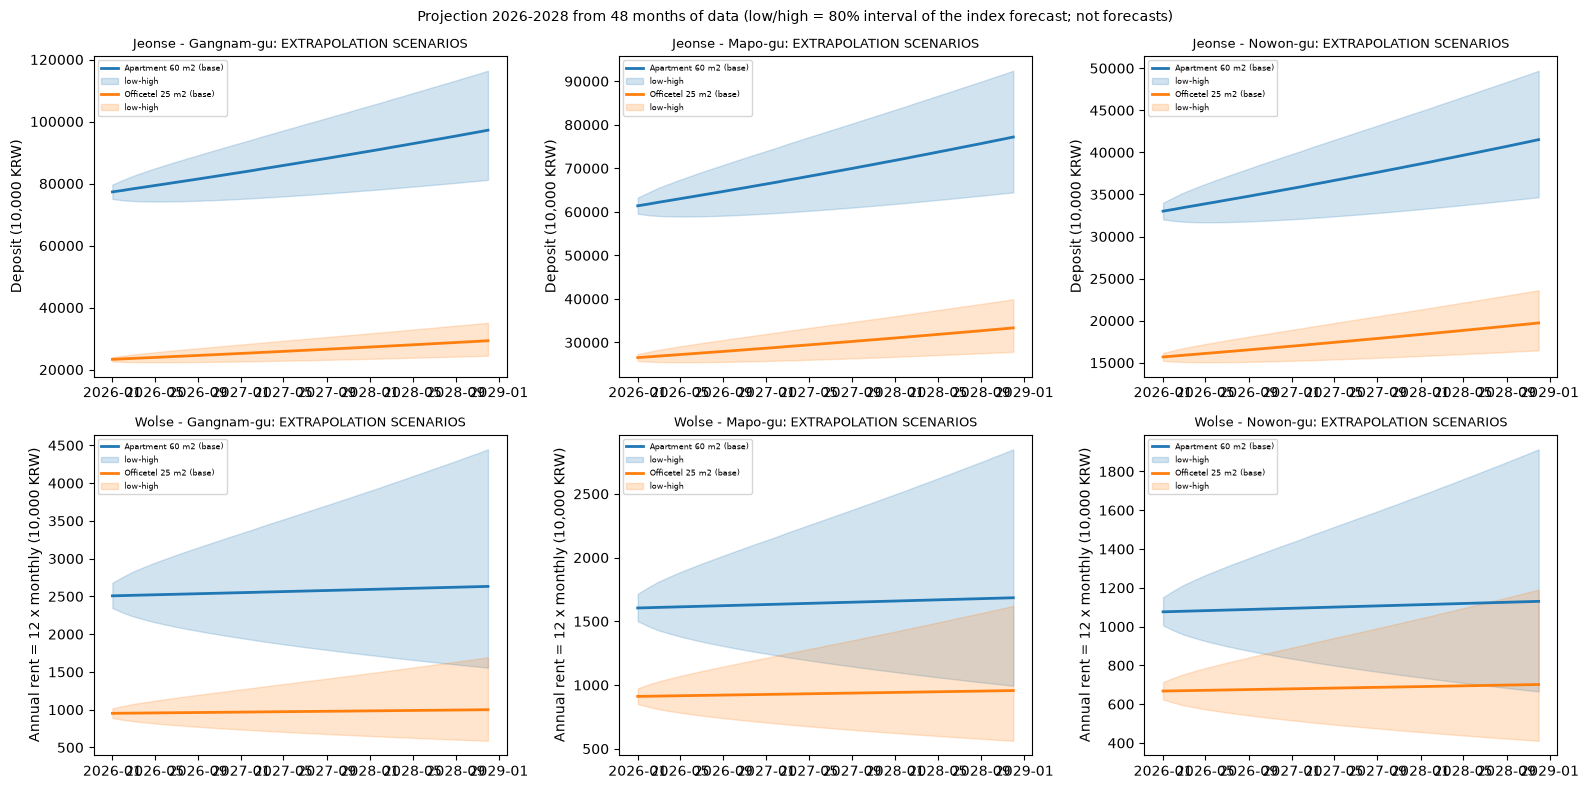

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for r, track in enumerate(config.TRACKS):
    for c, district in enumerate(['Gangnam-gu', 'Mapo-gu', 'Nowon-gu']):
        ax = axes[r, c]
        for btype, area, color in [('Apartment', 60.0, 'tab:blue'), ('Officetel', 25.0, 'tab:orange')]:
            table = projection[(track, f'{btype} {area:.0f} m2, {district}')]
            factor = 12 if track == 'wolse' else 1
            ax.plot(table.index, table['base'] * factor, color=color, lw=2, label=f'{btype} {area:.0f} m2 (base)')
            ax.fill_between(table.index, table['low'] * factor, table['high'] * factor, color=color, alpha=0.2, label='low-high')
        ax.set_title(f"{track.capitalize()} - {district}: EXTRAPOLATION SCENARIOS", fontsize=9)
        ax.set_ylabel('Deposit (10,000 KRW)' if track == 'jeonse' else 'Annual rent = 12 x monthly (10,000 KRW)')
        ax.legend(fontsize=6)
plt.suptitle('Projection 2026-2028 from 48 months of data (low/high = 80% interval of the index forecast; not forecasts)', fontsize=10)
plt.tight_layout(); plt.savefig(config.FIGURES_DIR / '09_projection_scenarios.png', dpi=130); plt.show()

**Interpretation.** The figure plots the base path and the low-high band of the two profiles per district for both tracks (values in the tables above). In Wolse the bands widen with the horizon, while in Jeonse the base path rises through a band built on a flat index forecast.

## Save the leaderboard

In [16]:
rows = []
for track in config.TRACKS:
    t = tables[track].set_index('model_id')
    pooled = {m: v['wape_pooled'] for m, v in pseudo_reports[track]['candidates'].items()}
    for _, r in runs[runs['track'] == track].iterrows():
        entry = {'track': track, 'model_id': r['model_id'], 'family': r['family'], 'valid': r['valid'], 'extrapolation': r['extrapolation'],
                 'behaviour': r['behaviour'], 'extrapolation_label_ok': r['extrapolation_label_ok'], 'can_extrapolate': r['can_extrapolate'], 'complexity': r['complexity'], 'n': r['n'],
                 **{c: r[c] for c in ['wape_pct', 'mae', 'mdape_pct', 'median_bias_pct', 'aggregate_bias_pct', 'mape_dq_median_pct', 'mape_dq_max_pct', 'rmse_log', 'r2_log']}}
        entry.update(in_pseudotest=r['model_id'] in pooled, pseudotest_wape_pooled=pooled.get(r['model_id'], np.nan))
        if r['valid'] and r['model_id'] in pooled:
            entry.update(diff_vs_leader=t.loc[r['model_id'], 'diff_vs_leader'], se_diff=t.loc[r['model_id'], 'se_diff'],
                         se_source=t.loc[r['model_id'], 'se_source'], tie_with_leader=bool(t.loc[r['model_id'], 'tie_with_leader']))
        entry.update(is_unconstrained_leader=r['model_id'] == selection[track]['stat_winner'] and bool(r['valid']),
                     is_chosen_model=r['model_id'] == selection[track]['winner'] and bool(r['valid']))
        rows.append(entry)
leaderboard = pd.DataFrame(rows)
leaderboard['rank_valid'] = leaderboard[leaderboard['valid']].groupby('track')['wape_pct'].rank(method='min')
leaderboard['rank_pseudotest'] = leaderboard[leaderboard['in_pseudotest']].groupby('track')['pseudotest_wape_pooled'].rank(method='min')
leaderboard = leaderboard.sort_values(['track', 'valid', 'wape_pct'], ascending=[True, False, True])
leaderboard.to_csv(config.METRICS_DIR / 'leaderboard.csv', index=False)
print(f'reports/metrics/leaderboard.csv: {len(leaderboard)} rows; figures:', sorted(p.name for p in config.FIGURES_DIR.glob('09_*.png')))
print(leaderboard[leaderboard['is_chosen_model'] | leaderboard['is_unconstrained_leader']][['track', 'model_id', 'rank_pseudotest', 'rank_valid', 'pseudotest_wape_pooled', 'wape_pct', 'is_unconstrained_leader', 'is_chosen_model']].to_string(index=False))

reports/metrics/leaderboard.csv: 76 rows; figures: ['09_leaderboard.png', '09_projection_scenarios.png']
 track              model_id  rank_pseudotest  rank_valid  pseudotest_wape_pooled  wape_pct  is_unconstrained_leader  is_chosen_model
jeonse        hgb_legal_dong           1.0000      2.0000                 16.3843   15.8354                     True            False
jeonse          rf_detrended           8.0000     13.0000                 18.5293   17.9091                    False             True
 wolse hgb_legal_dong_median           1.0000      1.0000                 39.7454   41.3097                     True            False
 wolse  hgb_detrended_median           2.0000      2.0000                 40.1784   42.4780                    False             True


**Interpretation.** The saved leaderboard has 76 rows. It records the pseudo-test rank and pooled WAPE next to the 2025 rank and WAPE, and marks the unconstrained leader and the chosen model of each track. In Jeonse, `hgb_legal_dong` is the unconstrained leader (pseudo-test rank 1, 2025 rank 2) and `rf_detrended` the chosen model (pseudo-test rank 8, 2025 rank 13). In Wolse, `hgb_legal_dong_median` is the unconstrained leader (rank 1 in both) and `hgb_detrended_median` the chosen model (rank 2 in both).

## Summary

- **Protocol.** The winners are selected on the 2023 and 2024 pseudo-tests with the most conservative of three standard errors and a behavioural extrapolation criterion; 2025 is reported once after the choice.
- **Winners that change.** Jeonse extrapolating: `hybrid_hgb` to `rf_detrended`; Wolse unconstrained: `hgb_legal_dong` to `hgb_legal_dong_median`; Wolse extrapolating: `hgb_detrended` to `hgb_detrended_median`. The Jeonse unconstrained choice (`hgb_legal_dong`) is unchanged.
- **2025 WAPE of the new choices.** Jeonse 15.8354% (unconstrained) and 17.9091% (extrapolating); Wolse 41.3097% and 42.4780%, against 44.3335% and 45.3293% under the previous protocol.
- **Cost of extrapolating.** 2.0737 points in Jeonse and 1.1682 points in Wolse.
- **Caveat.** The Jeonse scenario combines a model trend of 8.17% per year with a band built on a flat index forecast. The 2026-2028 paths are extrapolation scenarios from 48 months of data.
- **Disclosure.** 2025 was inspected in earlier iterations of the project.